# Figures 3 & 4 — RMSE/PBIAS Spatial Profile and Taylor Diagrams
## Reference Period 1995–2014

**Figure 3:** Two-panel dot-line chart showing RMSE (top) and |PBIAS| (bottom)
for all three approaches across 12 basins ordered Semi-arid → desert, with observed
annual mean as a secondary axis. Directly quantifies:


**Figure 4:** Taylor diagrams stratified by aridity class showing all 6 models
simultaneously — the standard tool for multi-model evaluation in climate science.
Normalised standard deviation (x-axis), correlation (angular axis), normalised
RMSE (concentric arcs). Points clustered near reference = good performance.
The arid-basin diagram visually explains the NSE paradox: all models fall far
from the reference point despite low absolute RMSE.


## 1. Import Libraries

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from pathlib import Path

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family"    : "Arial",
    "font.size"      : 10,
    "axes.titlesize" : 11,
    "axes.labelsize" : 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "savefig.dpi"    : 600,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})
print("Libraries loaded.")


Libraries loaded.


## 2. Configuration

In [2]:
BASE = Path(r"C:\Users\ASUS\Desktop\new.work.for.rainfall\comments")

ENS_COMP_CSV    = BASE / "validation" / "single.model" / "ensemble_comparison_basin.csv"
BASIN_MET_CSV   = BASE / "validation" / "single.model" / "basin_level_metrics.csv"
OBS_BASIN_CSV   = BASE / "basin mean from station and best approach" / "obs_basin_period_means.csv"
LTMM_WIDE_CSV   = BASE / "validation" / "single.model" / "ltmm_wide_obs_and_models.csv"
TABLE3_CSV      = BASE / "validation" / "single.model" / "table3_best_model_per_basin.csv"
RECOMMEND_CSV   = BASE / "validation" / "comparison" / "basin_approach_recommendation.csv"

FIG_DIR = BASE / "validation" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["CMCC-CM2-SR5","CNRM-ESM2-1","EC-Earth3-Veg",
          "IPSL-CM6A-LR","MPI-ESM1-2-LR","NorESM2-MM"]

# Colourblind-safe (Wong 2011)
MODEL_COLORS = {
    "CMCC-CM2-SR5"  : "#E69F00",
    "CNRM-ESM2-1"   : "#56B4E9",
    "EC-Earth3-Veg" : "#009E73",
    "IPSL-CM6A-LR"  : "#F0E442",
    "MPI-ESM1-2-LR" : "#0072B2",
    "NorESM2-MM"    : "#CC79A7",
}
MODEL_MARKERS = {
    "CMCC-CM2-SR5"  : "o",
    "CNRM-ESM2-1"   : "s",
    "EC-Earth3-Veg" : "^",
    "IPSL-CM6A-LR"  : "D",
    "MPI-ESM1-2-LR" : "P",
    "NorESM2-MM"    : "*",
}
APPROACH_STYLES = {
    "Best Single Model": {"color":"#0072B2","marker":"o","ls":"-",  "lw":2.0,"label":"Best Single Model"},
    "3-Model Ensemble" : {"color":"#009E73","marker":"s","ls":"--", "lw":1.8,"label":"3-Model Ensemble"},
    "6-Model Ensemble" : {"color":"#E69F00","marker":"^","ls":":",  "lw":1.6,"label":"6-Model Ensemble"},
}

print("Configuration loaded.")


Configuration loaded.


## 3. Load Data

In [3]:
# Ensemble comparison (3 approaches × 12 basins)
ens_comp = pd.read_csv(ENS_COMP_CSV)
ens_comp["Basin"] = ens_comp["Basin"].astype(str).str.strip()
ens_comp["absPBIAS"] = ens_comp["PBIAS"].abs()

# All 6 model basin metrics
basin_met = pd.read_csv(BASIN_MET_CSV)
basin_met["Basin"] = basin_met["Basin"].astype(str).str.strip()
basin_met["absPBIAS"] = basin_met["PBIAS"].abs()

# Observed basin means
obs_basin = pd.read_csv(OBS_BASIN_CSV)
obs_basin["Basin"] = obs_basin["Basin"].astype(str).str.strip()
obs_annual = dict(zip(obs_basin["Basin"], obs_basin["Annual_Mean"]))

# LTMM wide (for Taylor diagram normalisation)
ltmm = pd.read_csv(LTMM_WIDE_CSV)
ltmm["Basin"] = ltmm["Basin"].astype(str).str.strip()

# Best model per basin
table3 = pd.read_csv(TABLE3_CSV)
table3 = table3[~table3["Basin"].isin(["Mean","Std Dev","Median","IQR (Q1-Q3)","IQR (Q25-Q75)"])]
table3["Basin"] = table3["Basin"].astype(str).str.strip()
best_model_dict = dict(zip(table3["Basin"], table3["Best_Model"]))

# Recommended approach
recommend = pd.read_csv(RECOMMEND_CSV)
recommend["Basin"] = recommend["Basin"].astype(str).str.strip()
recommend_dict = dict(zip(recommend["Basin"], recommend["Recommended_Approach"]))

# Basin order: humid → arid
all_basins = ens_comp["Basin"].unique()
basin_order = sorted(all_basins, key=lambda b: obs_annual.get(b,0), reverse=True)
basin_labels = [b.replace(" (JORDAN)","").replace("W. ARABA NORTH","W.A.N.")
                 .replace("JORDAN VALLY","JO.Valley").replace("AMMAN ZARQA","Amman Z.")
                 for b in basin_order]

# Aridity groups
humid_basins  = [b for b in basin_order if obs_annual.get(b,0) >= 300]
semi_basins   = [b for b in basin_order if 100 <= obs_annual.get(b,0) < 300]
arid_basins   = [b for b in basin_order if obs_annual.get(b,0) < 100]
print(f"Humid: {len(humid_basins)}  Semi-arid: {len(semi_basins)}  Arid: {len(arid_basins)}")


Humid: 3  Semi-arid: 6  Arid: 3


## 4. Figure 3 — RMSE and PBIAS Spatial Profile

Saved: C:\Users\ASUS\Desktop\new.work.for.rainfall\comments\validation\figures\Figure3_RMSE_PBIAS_spatial.png
Saved: C:\Users\ASUS\Desktop\new.work.for.rainfall\comments\validation\figures\Figure3_RMSE_PBIAS_spatial.pdf


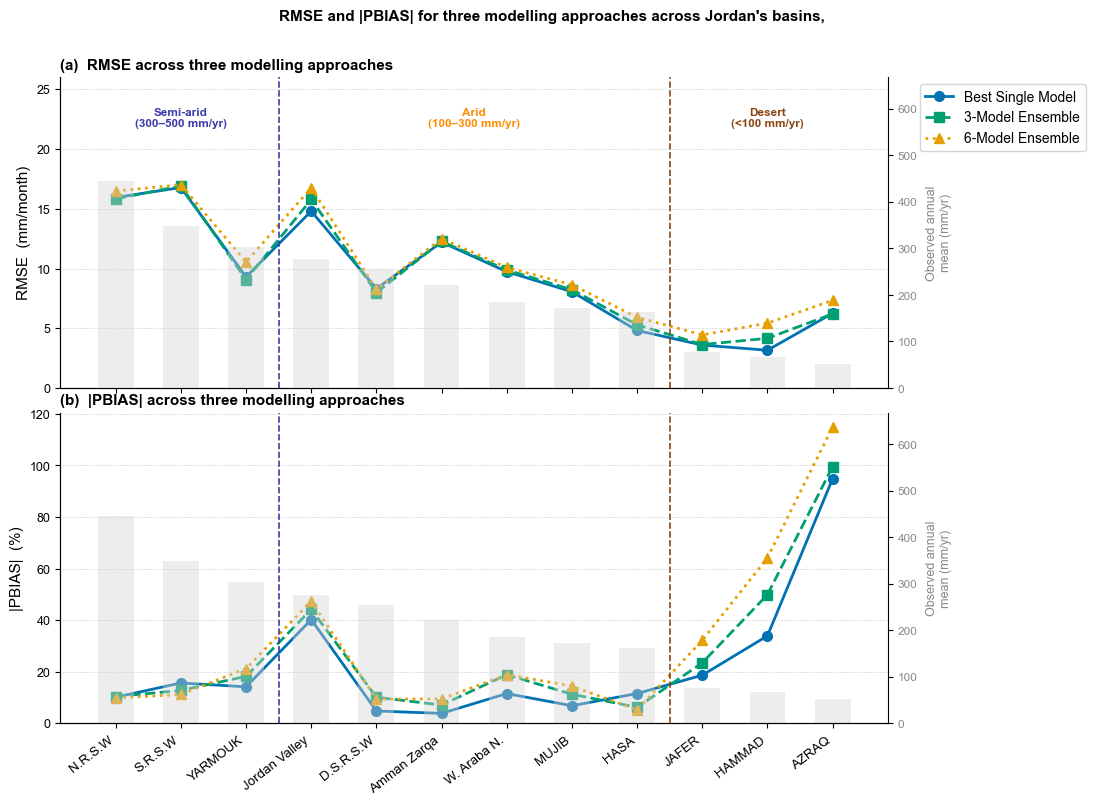

In [8]:
# ── Figure 3: RMSE and |PBIAS| spatial profile ────────────────────────────────
fig3, (ax_rmse, ax_pbias) = plt.subplots(
    2, 1, figsize=(12.0, 8.5), sharex=True,
    gridspec_kw={"hspace": 0.08}
)
# right=0.78 leaves room for twin-axis + legend outside; top for suptitle
plt.subplots_adjust(left=0.09, right=0.78, top=0.91, bottom=0.15)

x = np.arange(len(basin_order))
obs_ann_vals = [obs_annual.get(b, np.nan) for b in basin_order]

humid_n = sum(1 for b in basin_order if obs_annual.get(b, 0) >= 300)
semi_n  = sum(1 for b in basin_order if obs_annual.get(b, 0) >= 100)

# ── Top panel: RMSE ───────────────────────────────────────────────────────────
ax2 = ax_rmse.twinx()

for approach_label, style in APPROACH_STYLES.items():
    rmse_vals = [ens_comp.loc[(ens_comp["Basin"]==b) &
                  (ens_comp["Approach"]==approach_label), "RMSE"].iloc[0]
                 if not ens_comp[(ens_comp["Basin"]==b) &
                  (ens_comp["Approach"]==approach_label)].empty else np.nan
                 for b in basin_order]
    ax_rmse.plot(x, rmse_vals, color=style["color"], linestyle=style["ls"],
                 linewidth=2.0, marker=style["marker"], markersize=7,
                 zorder=4, label=style["label"])

ax2.bar(x, obs_ann_vals, width=0.55, color="lightgrey", alpha=0.40, zorder=1)
ax2.set_ylabel("Observed annual\nmean (mm/yr)", fontsize=9,
               color="#888888", labelpad=6)
ax2.tick_params(axis="y", labelcolor="#888888", labelsize=8.5)
ax2.set_ylim(0, max(obs_ann_vals) * 1.5)
ax2.spines["right"].set_visible(True)
ax2.spines["top"].set_visible(False)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))

ax_rmse.set_ylabel("RMSE  (mm/month)", fontsize=11)
ax_rmse.set_ylim(0, 26)
ax_rmse.yaxis.grid(True, linestyle=":", linewidth=0.6, color="grey", alpha=0.5)
ax_rmse.set_axisbelow(True)
ax_rmse.set_title("(a)  RMSE across three modelling approaches",
                  fontsize=11, pad=6, loc="left", fontweight="bold")

# Zone dividers
for axt in [ax_rmse, ax2]:
    axt.axvline(humid_n - 0.5, color="#3a3aaa", ls="--", lw=1.2, alpha=0.7, zorder=5)
    axt.axvline(semi_n  - 0.5, color="#8b4513", ls="--", lw=1.2, alpha=0.7, zorder=5)

# Zone labels — top of each zone, with opaque white background
for txt, xpos, col in [
    ("Semi-arid\n(300–500 mm/yr)",        humid_n / 2 - 0.5,                     "#3a3aaa"),
    ("Arid\n(100–300 mm/yr)", (humid_n + semi_n) / 2 - 0.5,          "darkorange"),
    ("Desert\n(<100 mm/yr)",         (semi_n + len(basin_order)) / 2 - 0.5,  "#8b4513"),
]:
    ax_rmse.text(xpos, 23.5, txt, fontsize=8.5, color=col,
                 ha="center", va="top", fontweight="bold",
                 bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=1.5))

# Legend placed BELOW the twin axis, outside the plot — no overlap possible
leg = ax_rmse.legend(loc="upper left", fontsize=10, frameon=True,
                     edgecolor="lightgrey", framealpha=0.95,
                     bbox_to_anchor=(1.03, 1.0),
                     bbox_transform=ax_rmse.transAxes)

# ── Bottom panel: |PBIAS| ─────────────────────────────────────────────────────
ax2b = ax_pbias.twinx()

for approach_label, style in APPROACH_STYLES.items():
    pbias_vals = [abs(ens_comp.loc[(ens_comp["Basin"]==b) &
                   (ens_comp["Approach"]==approach_label), "PBIAS"].iloc[0])
                  if not ens_comp[(ens_comp["Basin"]==b) &
                   (ens_comp["Approach"]==approach_label)].empty else np.nan
                  for b in basin_order]
    ax_pbias.plot(x, pbias_vals, color=style["color"], linestyle=style["ls"],
                  linewidth=2.0, marker=style["marker"], markersize=7, zorder=4)

ax2b.bar(x, obs_ann_vals, width=0.55, color="lightgrey", alpha=0.40, zorder=1)
ax2b.set_ylabel("Observed annual\nmean (mm/yr)", fontsize=9,
                color="#888888", labelpad=6)
ax2b.tick_params(axis="y", labelcolor="#888888", labelsize=8.5)
ax2b.set_ylim(0, max(obs_ann_vals) * 1.5)
ax2b.spines["right"].set_visible(True)
ax2b.spines["top"].set_visible(False)
ax2b.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))

# 25% threshold line
# Label at far right of the line, above it, with white box
ax_pbias.text(len(basin_order) - 0.5, 26.5,
              "",
              fontsize=8, color="crimson", ha="right", va="bottom",
              bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=1))

ax_pbias.set_ylabel("|PBIAS|  (%)", fontsize=11)
ax_pbias.set_ylim(0, None)
ax_pbias.yaxis.grid(True, linestyle=":", linewidth=0.6, color="grey", alpha=0.5)
ax_pbias.set_axisbelow(True)
ax_pbias.set_title("(b)  |PBIAS| across three modelling approaches",
                   fontsize=11, pad=6, loc="left", fontweight="bold")

for axt in [ax_pbias, ax2b]:
    axt.axvline(humid_n - 0.5, color="#3a3aaa", ls="--", lw=1.2, alpha=0.7, zorder=5)
    axt.axvline(semi_n  - 0.5, color="#8b4513", ls="--", lw=1.2, alpha=0.7, zorder=5)

# ── X-axis labels ─────────────────────────────────────────────────────────────
basin_labels_clean = []
for b in basin_order:
    name = (b.replace(" (JORDAN)", "")
             .replace("W. ARABA NORTH", "W. Araba N.")
             .replace("JORDAN VALLY", "Jordan Valley")
             .replace("AMMAN ZARQA", "Amman Zarqa"))
    basin_labels_clean.append(name)

ax_pbias.set_xticks(x)
ax_pbias.set_xticklabels(basin_labels_clean, rotation=38, ha="right", fontsize=9.5)
ax_pbias.tick_params(axis="x", pad=4)

fig3.suptitle(
    "RMSE and |PBIAS| for three modelling approaches across Jordan's basins,\n"
    ,
    fontsize=11, fontweight="bold", y=0.99
)

for fmt in ["png", "pdf"]:
    out = FIG_DIR / f"Figure3_RMSE_PBIAS_spatial.{fmt}"
    fig3.savefig(out, dpi=600, bbox_inches="tight", format=fmt, facecolor="white")
    print(f"Saved: {out}")

plt.show()


## 5. Taylor Diagram Functions

In [5]:
def taylor_diagram(ax, stats_list, ref_std=1.0, max_std=1.8,
                   colors=None, markers=None, labels=None,
                   title="", show_legend=True):
    """Normalised Taylor diagram — clean, no overlapping elements."""
    ax.set_aspect("equal")
    ax.set_xlim(-0.05, max_std * 1.05)
    ax.set_ylim(-0.12, max_std * 1.05)

    # Remove all default spines and ticks — diagram is self-describing
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    # ── Std deviation circles ──────────────────────────────────────────────────
    std_ticks = [s for s in [0.5, 1.0, 1.5, 2.0, 2.5] if s <= max_std + 0.01]
    for std_val in std_ticks:
        circle = plt.Circle((0, 0), std_val, fill=False,
                             color="lightgrey", lw=0.8, zorder=1)
        ax.add_patch(circle)
        # Label ON the x-axis (y=0) below the circle, clear of axis label
        ax.text(std_val, -0.09, f"{std_val:.1f}",
                fontsize=8, color="#555555",
                ha="center", va="top", clip_on=False)

    # ── Outer arc ─────────────────────────────────────────────────────────────
    theta_arc = np.linspace(0, np.pi / 2, 300)
    ax.plot(max_std * np.cos(theta_arc), max_std * np.sin(theta_arc),
            color="#aaaaaa", lw=1.0, zorder=2)

    # ── X and Y axis lines ─────────────────────────────────────────────────────
    ax.axvline(0, color="#aaaaaa", lw=0.8, zorder=1)

    # ── Correlation radial lines + labels ────────────────────────────────────
    r_values = [0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
    for r_val in r_values:
        angle = np.arccos(r_val)
        x_end = max_std * np.cos(angle)
        y_end = max_std * np.sin(angle)
        ax.plot([0, x_end], [0, y_end], color="lightgrey",
                lw=0.7, linestyle="--", zorder=1)
        # Label outside the outer arc, rotated to follow the radial
        off = max_std * 0.10
        lx = (max_std + off) * np.cos(angle)
        ly = (max_std + off) * np.sin(angle)
        rot = np.degrees(angle) - 90
        ax.text(lx, ly, f"{r_val}", fontsize=7.5, color="#555555",
                va="center", ha="center", clip_on=False, rotation=rot)

    # ── "Correlation" axis label along the outer arc ─────────────────────────
    label_angle = np.deg2rad(52)
    off2 = max_std * 0.20
    ax.text((max_std + off2) * np.cos(label_angle),
            (max_std + off2) * np.sin(label_angle),
            "Correlation", fontsize=8.5, color="#444444",
            rotation=np.degrees(label_angle) - 90,
            ha="center", va="center", clip_on=False)

    # ── NRMSE contours — labels placed at ~75° where data is sparse ───────────
    nrmse_vals = [0.5, 1.0, 1.5]
    for nrmse in nrmse_vals:
        arc_theta = np.linspace(0, np.pi, 400)
        xc = ref_std + nrmse * np.cos(arc_theta)
        yc = nrmse * np.sin(arc_theta)
        mask = (xc >= -0.02) & (xc <= max_std * 1.02) & \
               (yc >= -0.02) & (yc <= max_std * 1.02)
        if mask.any():
            ax.plot(xc[mask], yc[mask], color="#aaaaaa",
                    lw=0.9, linestyle=":", zorder=1)
            # Label near top of arc (high angle) where no data points cluster
            label_angle = np.deg2rad(75)
            xlbl = ref_std + nrmse * np.cos(label_angle)
            ylbl = nrmse * np.sin(label_angle)
            if 0 <= xlbl <= max_std and 0 <= ylbl <= max_std:
                ax.text(xlbl, ylbl, f"NRMSE={nrmse:.1f}",
                        fontsize=6.5, color="#888888",
                        ha="left", va="center",
                        bbox=dict(facecolor="white", edgecolor="none",
                                  alpha=0.85, pad=0.5))

    # ── Reference point ────────────────────────────────────────────────────────
    ax.plot(ref_std, 0, marker="*", color="black", markersize=13,
            zorder=7, markeredgewidth=0.5, markeredgecolor="white",
            label="Observed (reference)")

    # ── Model points ───────────────────────────────────────────────────────────
    for i, (r, norm_std) in enumerate(stats_list):
        x_pt = norm_std * r
        y_pt = norm_std * np.sin(np.arccos(np.clip(r, -1, 1)))
        ax.scatter(x_pt, y_pt,
                   c=colors[i]  if colors  else "blue",
                   marker=markers[i] if markers else "o",
                   s=75, zorder=6, edgecolors="white", linewidths=0.6,
                   label=labels[i] if labels else f"M{i+1}")

    # ── Axis labels — placed manually to avoid tick overlap ───────────────────
    # X label centred below the std tick labels
    ax.text(max_std / 2, -0.20, "Normalised Standard Deviation",
            fontsize=10, ha="center", va="top", clip_on=False)
    # Y label rotated, left of axis
    ax.text(-0.20, max_std / 2, "Normalised Standard Deviation",
            fontsize=10, ha="center", va="center",
            rotation=90, clip_on=False)

    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)

    if show_legend:
        ax.legend(fontsize=8, loc="upper right", frameon=True,
                  edgecolor="lightgrey", markerscale=1.1)


print("Taylor diagram function defined.")


Taylor diagram function defined.


## 6. Figure 4 — Taylor Diagrams by Aridity Class

Computing Taylor statistics ...
Done.
Saved: C:\Users\ASUS\Desktop\new.work.for.rainfall\comments\validation\figures\Figure4_Taylor_diagrams.png
Saved: C:\Users\ASUS\Desktop\new.work.for.rainfall\comments\validation\figures\Figure4_Taylor_diagrams.pdf


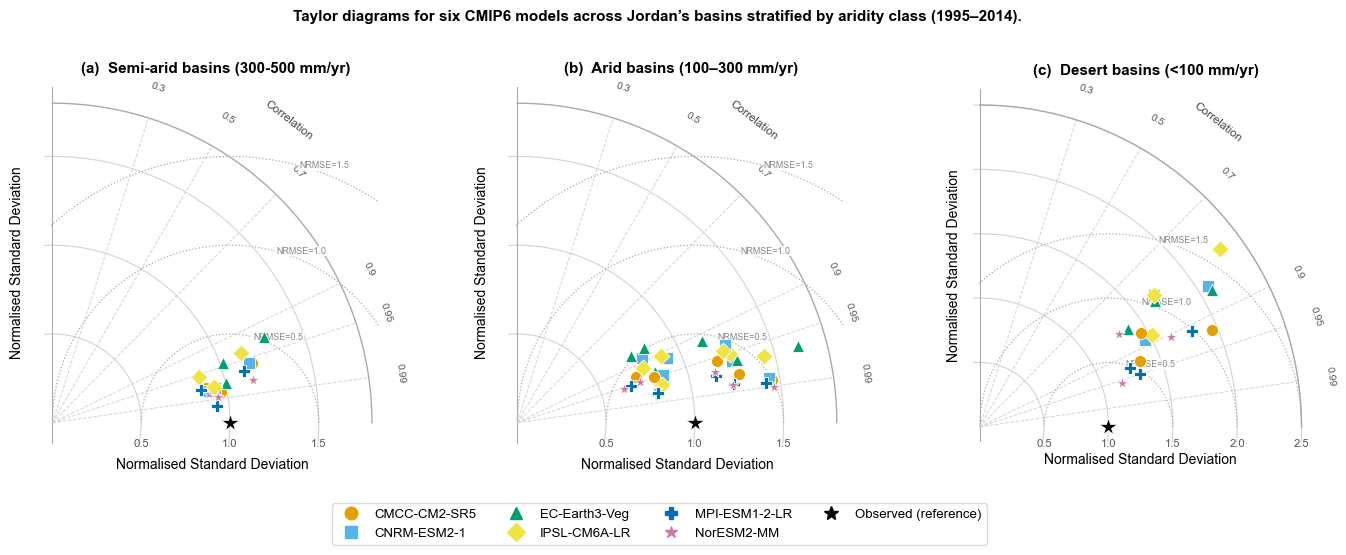

Figure 4 complete.


In [6]:
# ── Compute normalised statistics per basin per model ─────────────────────────
def get_taylor_stats(ltmm_df, basin, model):
    bdf = ltmm_df[ltmm_df["Basin"] == basin]
    r_vals, ns_vals = [], []
    for sid, grp in bdf.groupby("Station_ID"):
        grp = grp.sort_values("Month")
        obs = grp["Obs"].values
        mod = grp[model].values if model in grp.columns else None
        if mod is None or np.any(np.isnan(obs)) or np.any(np.isnan(mod)):
            continue
        std_obs = np.std(obs)
        if std_obs < 0.1:
            continue
        r = np.corrcoef(obs, mod)[0, 1]
        r_vals.append(r)
        ns_vals.append(np.std(mod) / std_obs)
    if not r_vals:
        return np.nan, np.nan
    return float(np.mean(r_vals)), float(np.mean(ns_vals))

print("Computing Taylor statistics ...")
taylor_stats = {}
for basin in basin_order:
    taylor_stats[basin] = {}
    for model in MODELS:
        r, ns = get_taylor_stats(ltmm, basin, model)
        taylor_stats[basin][model] = (r, ns)
print("Done.")

# ── Build figure ──────────────────────────────────────────────────────────────
# 3 equal-size panels side by side; large enough for readable labels
FIG4_W = 14.0   # ~355 mm — each panel gets ~108 mm
FIG4_H = 5.5    # ~140 mm

fig4, axes4 = plt.subplots(1, 3, figsize=(FIG4_W, FIG4_H))
plt.subplots_adjust(wspace=0.35, left=0.06, right=0.97,
                    top=0.88, bottom=0.18)

panel_info = [
    ("(a)  Semi-arid basins (300-500 mm/yr)",         humid_basins, 1.8),
    ("(b)  Arid basins (100\u2013300 mm/yr)", semi_basins,  1.8),
    ("(c)  Desert basins (<100 mm/yr)",           arid_basins,  2.5),
]

for ax, (title, basins_in_class, max_std) in zip(axes4, panel_info):
    stats_all, colors_all, markers_all, labels_all = [], [], [], []

    for basin in basins_in_class:
        for model in MODELS:
            r, ns = taylor_stats[basin].get(model, (np.nan, np.nan))
            if np.isnan(r) or np.isnan(ns):
                continue
            stats_all.append((r, ns))
            colors_all.append(MODEL_COLORS[model])
            markers_all.append(MODEL_MARKERS[model])
            labels_all.append(model)

    taylor_diagram(ax, stats_all, ref_std=1.0, max_std=max_std,
                   colors=colors_all, markers=markers_all,
                   labels=labels_all, title=title,
                   show_legend=False)

# ── Shared legend — two rows, centred below panels ────────────────────────────
legend_elements = [
    mlines.Line2D([0], [0], color=MODEL_COLORS[m], marker=MODEL_MARKERS[m],
                  linestyle="None", markersize=9, label=m)
    for m in MODELS
] + [
    mlines.Line2D([0], [0], color="black", marker="*",
                  linestyle="None", markersize=10, label="Observed (reference)"),
]
fig4.legend(handles=legend_elements, loc="lower center", ncol=4,
            fontsize=9.5, frameon=True, edgecolor="lightgrey",
            bbox_to_anchor=(0.5, 0.01))

# ── Suptitle (two clean lines) ────────────────────────────────────────────────
fig4.suptitle(
    "Taylor diagrams for six CMIP6 models across Jordan\u2019s basins "
    "stratified by aridity class (1995\u20132014). "
 ,
    fontsize=11, fontweight="bold", y=0.995
)

for fmt in ["png", "pdf"]:
    out = FIG_DIR / f"Figure4_Taylor_diagrams.{fmt}"
    fig4.savefig(out, dpi=600, bbox_inches="tight", format=fmt, facecolor="white")
    print(f"Saved: {out}")

plt.show()
print("Figure 4 complete.")


## 7. Summary of Output Files

In [7]:
print("Figures saved to:", FIG_DIR)
print()
for f in sorted(FIG_DIR.iterdir()):
    if f.is_file():
        sz = f.stat().st_size / 1024
        unit = "KB"
        if sz > 1024:
            sz /= 1024; unit = "MB"
        print(f"  {f.name:<45} {sz:>7.1f} {unit}")


Figures saved to: C:\Users\ASUS\Desktop\new.work.for.rainfall\comments\validation\figures

  15_Figures3_4_RMSE_Taylor.ipynb                 168.9 KB
  Fig1_model_spread_stats.csv                       0.5 KB
  Figure1_seasonal_cycle.pdf                       54.7 KB
  Figure1_seasonal_cycle.png                        2.0 MB
  Figure2_ranking_heatmap.old.png                   1.9 MB
  Figure2_ranking_heatmap.pdf                     130.8 KB
  Figure2_ranking_heatmap.png                       1.9 MB
  Figure3_RMSE_PBIAS_spatial.pdf                   42.1 KB
  Figure3_RMSE_PBIAS_spatial.png                    1.2 MB
  Figure4_Taylor_diagrams.pdf                      50.1 KB
  Figure4_Taylor_diagrams.png                       1.3 MB
  note about fig 2.txt                              0.2 KB
